In [19]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split

In [20]:
def create_datasets(samples=300):
    images=[]
    masks=[]

    for _ in range(samples):

        img=np.zeros((img_size,img_size,3),dtype=np.uint8)
        mask=np.zeros((img_size,img_size,1),dtype=np.uint8)

        x=np.random.randint(30,100)
        y=np.random.randint(30,100)
        r=np.random.randint(10,30)

        cv2.circle(img,(x,y),r,(255,255,255),-1)
        cv2.circle(mask,(x,y),r,255,-1)

        images.append(img/255.0)
        masks.append(mask/255.0)

    return np.array(images), np.array(masks)

In [21]:
X,y=create_datasets(300)

print(X.shape)

(300, 128, 128, 3)


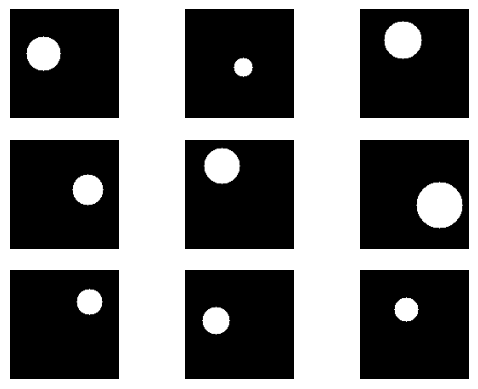

In [22]:
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X[i])
    plt.axis('off')
plt.show()

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
#====================================
#======= Convoltional Block==========
#====================================
from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, MaxPool2D, Conv2DTranspose, Concatenate, Input
from tensorflow.keras.models import Model
def conv_block(x,filters):
  x=Conv2D(filters,3,padding='same')(x)
  x=Conv2D(filters,3,padding='same')(x)
  return x

In [25]:
from tensorflow.keras.layers import UpSampling2D
# ============================================
# Buildeing U net Arctechture
# ============================================

inputs=Input((img_size,img_size,3))

#Encoder
c1=conv_block(inputs,32)
p1=MaxPool2D()(c1)

c2=conv_block(p1,64) # Changed from inputs to p1
p2=MaxPool2D()(c2)

c3=conv_block(p2,128) # Changed from inputs to p2
p3=MaxPool2D()(c3)

#Bottelneck
bn=conv_block(p3,256) # Changed from inputs to p3

#Decoder
u1=UpSampling2D()(bn)
concatn1=Concatenate()([u1,c3])
c4=conv_block(concatn1,128)
u2=UpSampling2D()(c4)
concatn2=Concatenate()([u2,c2])
c5=conv_block(concatn2,64)
u3=UpSampling2D()(c5)
concatn3=Concatenate()([u3,c1])
c6=conv_block(concatn3,32)

output=Conv2D(1,1,activation='sigmoid')(c6)

model=Model(inputs,output)

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_31 (Conv2D)  │ (None, 128, 128,  │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_32 (Conv2D)  │ (None, 128, 128,  │      9,248 │ conv2d_31[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_9     │ (None, 64, 64,    │          0 │ conv2d_32[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_9[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 64, 64,    │     36,928 │ conv2d_33[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 32, 32,    │          0 │ conv2d_34[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_10… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_35[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 16, 16,    │          0 │ conv2d_36[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 16, 16,    │    295,168 │ max_pooling2d_11… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_38 (Conv2D)  │ (None, 16, 16,    │    590,080 │ conv2d_37[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_4     │ (None, 32, 32,    │          0 │ conv2d_38[0][0]   │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 32, 32,    │          0 │ up_sampling2d_4[… │
│ (Concatenate)       │ 384)              │            │ conv2d_36[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 32, 32,    │    442,496 │ concatenate_4[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 32, 32,    │    147,584 │ conv2d_39[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_5     │ (None, 64, 64,    │          0 │ conv2d_40[0][0] 

 Total params: 1,946,881 (7.43 MB)

 Trainable params: 1,946,881 (7.43 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
history=model.fit(X_train,y_train,epochs=10,validation_split=0.2,batch_size=8)

Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - accuracy: 0.8082 - loss: 0.7616 - val_accuracy: 0.9646 - val_loss: 0.3328
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9505 - loss: 0.4580 - val_accuracy: 0.9922 - val_loss: 0.0263
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9967 - loss: 0.0116 - val_accuracy: 0.9984 - val_loss: 0.0050
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9986 - loss: 0.0046 - val_accuracy: 0.9991 - val_loss: 0.0033
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9991 - loss: 0.0032 - val_accuracy: 0.9992 - val_loss: 0.0029
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9992 - loss: 0.0028 - val_accuracy: 0.9994 - val_loss: 0.0024
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9994 - loss: 0.0024 - val_accuracy: 0.9995 - val_loss: 0.0021
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9995 - loss: 0.0021 - val_accuracy: 0.9997 - 

In [28]:
loss,acc=model.evaluate(X_test,y_test)
print(f'Loss: {loss}, Accuracy: {acc}')

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 4s/step - accuracy: 0.9997 - loss: 0.0015
Loss: 0.0014841527445241809, Accuracy: 0.9996938109397888
